## Setup dan lokasi data

In [ ]:
import glob, os
from pathlib import Path

import duckdb
import plotly.express as px
import polars as pl

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(80)

CANDIDATES = [
    "../data/raw/*.parquet", "data/raw/*.parquet",
    "../data/raw/*.parquet", "data/raw/*.parquet",
]
DATA_PATH = next((p for p in CANDIDATES if glob.glob(p)), None)
assert DATA_PATH, "File parquet tidak ketemu, cek folder data/raw/"

FILES = sorted(f.replace("\\", "/") for f in glob.glob(DATA_PATH))
ROOT = "../" if DATA_PATH.startswith("../") else ""
OUT_DIR = Path(ROOT + "output")
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

total_bytes = sum(os.path.getsize(f) for f in FILES)
print(f"Path        : {DATA_PATH}")
print(f"Jumlah file : {len(FILES)}")
print(f"Total ukuran: {total_bytes / 1e6:,.0f} MB ({total_bytes / 1e9:.2f} GB)")


def collect(lf):
    try:
        return lf.collect(engine="streaming")
    except TypeError:
        return lf.collect(streaming=True)

Path        : ../data/raw/indonesian_political/*.parquet
Jumlah file : 21
Total ukuran: 4,656 MB (4.66 GB)


## Skema dan jumlah baris 

In [11]:
FILES = valid_files

print(f"Jumlah file valid: {len(FILES)}")

lf = pl.scan_parquet(FILES)

schema = lf.collect_schema()

N_ROWS = lf.select(pl.len()).collect().item()

print(f"Baris : {N_ROWS:,}")
print(f"Kolom : {len(schema)}")

Jumlah file valid: 18
Baris : 1,332,236
Kolom : 15


In [12]:
file_rows = pl.DataFrame({
    "file": [os.path.basename(f) for f in FILES],
    "baris": [
        pl.scan_parquet(f).select(pl.len()).collect().item()
        for f in FILES
    ],
})

## Cuplikan data

In [13]:
lf.head(5).collect()

id,news_title,news_source,news_author,news_hostname,news_date,news_text,news_tags,news_kabkot,news_intent,news_image,update_date,create_date,news_guid,news_raw_data
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1924973""","""Dana Kegiatan Isbat Nikah Bakal Diajukan di APBD Perubahan 2026""","""https://radarutara.disway.id/mukomuko/read/678652/dana-kegiatan-isbat-nikah-baka…","""Wahyudi""","""disway.id""","""2026-04-27 01:30:00+00:00""","""Dana Kegiatan Isbat Nikah Bakal Diajukan di APBD Perubahan 2026 Kabag Kesra Setd…","""['apbd perubahan 2026', 'diajukan di apbd perubahan 2026', 'kegiatan isbat nikah…","""Kabupaten Mukomuko""","""{'intent': 'lapor_informasi', 'places': [{'name': 'Mukomuko', 'type': 'regency',…",null,"""2026-04-27 03:08:50.074774+00:00""",null,"""CBMiswFBVV95cUxOaDhvMVNUZFRlelpsSGNoNXUzMFFVbmNlTDk0WEJXdm0zZVcycHFpdWRKSm91TXUw…","""{'id': None, 'url': 'https://radarutara.disway.id/mukomuko/read/678652/dana-kegi…"
"""1925951""","""Satu Orang Meninggal dari Insiden Tabrak Lari Beruntun di Samarinda - ayokaltim.…","""https://www.ayokaltim.com/satu-orang-meninggal-dari-insiden-tabrak-lari-beruntun…","""Iswanto""","""ayokaltim.com""","""2026-04-27 03:19:46+00:00""","""Satu Orang Meninggal dari Insiden Tabrak Lari Beruntun di Samarinda SAMARINDA, A…","""['Peristiwa di Samarinda;Tabrak Lari']""","""Kota Samarinda""","""{'intent': 'lapor_informasi', 'places': [{'name': 'Samarinda', 'type': 'city', '…",null,"""2026-04-27 05:26:20.891514+00:00""",null,"""CBMimgFBVV95cUxQSkNndGh1VGxOekE1MFgwZ1kwM0p2bkc4YVZ1RjVJQmhyZGVtZ3JMbmVRRUVGUUJs…","""{'id': None, 'url': 'https://www.ayokaltim.com/satu-orang-meninggal-dari-insiden…"
"""1925952""","""DPRD Bongkar Ketidaksesuaian Laporan Pendidikan, Abdul Rohim Temukan Sekolah Bel…","""https://infosatu.co/dprd-bongkar-ketidaksesuaian-laporan-pendidikan-abdul-rohim-…","""Emmy Haryanti""","""infosatu.co""","""2026-04-27 03:59:29+00:00""","""Samarinda, infosatu.co – Klaim capaian pembangunan sektor pendidikan di Kota Sam…","""['Abdul rohim;DPRD Samarinda;LKPj;Pendidikan']""","""Kota Samarinda""","""{'intent': 'lapor_informasi', 'places': [{'name': 'Samarinda', 'type': 'city', '…",null,"""2026-04-27 05:26:20.891632+00:00""",null,"""CBMirwFBVV95cUxOMFMxOGNOWlZtT1dTV3FmX3VYUENRdk1pMlZMMVNOdm5uX0d3SG0tdDBHZjV3d1Fo…","""{'id': None, 'url': 'https://infosatu.co/dprd-bongkar-ketidaksesuaian-laporan-pe…"
"""1925953""","""DPRD Dorong Penanganan Banjir Menyeluruh, Sodetan ke Mahakam Dinilai Jadi Solusi…","""https://infosatu.co/dprd-dorong-penanganan-banjir-menyeluruh-sodetan-ke-mahakam-…","""Emmy Haryanti""","""infosatu.co""","""2026-04-27 01:43:24+00:00""","""Samarinda, infosatu.co – Dewan Perwakilan Rakyat Daerah (DPRD) Kota Samarinda me…","""['Banjir;Deni Hakim Anwar;DPRD Samarinda']""","""Kota Samarinda""","""{'intent': 'lapor_informasi', 'places': [{'name': 'Samarinda', 'type': 'city', '…",null,"""2026-04-27 05:26:20.891650+00:00""",null,"""CBMirwFBVV95cUxPMGdaZU9wVTR0ZGVCcFRnT0pzaGg0SjhWSkVoVXJpbTgyMjVzeEJpN0ZVSHhkQmlx…","""{'id': None, 'url': 'https://infosatu.co/dprd-dorong-penanganan-banjir-menyeluru…"
"""1924974""","""Kepung Pasar Karang Nabire, Massa Demo Tuntut Prabowo Tarik Pasukan dari Distrik…","""https://papuatengah.tribunnews.com/nabire/5431/kepung-pasar-karang-nabire-massa-…","""Calvin Eluis Erari""","""tribunnews.com""","""2026-04-27 02:14:39+00:00""","""Demo di Nabire Kepung Pasar Karang Nabire, Massa Demo Tuntut Prabowo Tarik Pasuk…","""[]""","""Kabupaten Nabire""","""{'intent': 'lapor_informasi', 'places': [{'name': 'Pasar Karang', 'type': 'landm…",null,"""2026-04-27 03:09:48.135779+00:00""",null,"""CBMi1wFBVV95cUxNbHNySlhzMDFFV1FtVFhmVDR0NXpCdFdQNkR5elg0RHMyLUlCUGZGZXhMX09vdUpr…","""{'id': None, 'url': 'https://papuatengah.tribunnews.com/nabire/5431/kepung-pasar…"


## SUMMARIZE dari DuckDB

In [14]:
SUMMARIZE_FILES = FILES[:3]
MEMORY_LIMIT = "4GB"  

con = duckdb.connect()
con.execute(f"SET memory_limit='{MEMORY_LIMIT}'")


def q(sql):
    res = con.execute(sql)
    try:
        return res.pl()
    except Exception:
        rows = res.fetchall()
        return pl.DataFrame(rows, schema=[d[0] for d in res.description], orient="row")


def files_sql(files):
    return "[" + ", ".join(f"'{f}'" for f in files) + "]"


scalar_cols = [c for c, t in schema.items() if not t.is_nested()]
cols_sql = ", ".join(f'"{c}"' for c in scalar_cols)

summ = q(f"SUMMARIZE SELECT {cols_sql} FROM read_parquet({files_sql(SUMMARIZE_FILES)})")
summ.write_csv(OUT_DIR / "profiling_summarize.csv")
summ.select(["column_name", "column_type", "min", "max", "approx_unique", "avg", "null_percentage", "count"])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

column_name,column_type,min,max,approx_unique,avg,null_percentage,count
str,str,str,str,i64,i32,"decimal[9,2]",i64
"""id""","""VARCHAR""","""1""","""99996""",240990,null,0.00,222041
"""news_title""","""VARCHAR""","""""7 Dosa” Dirus Perumda Tirta Bhagasasi, Ade Efendi Zarkasih: Dari Penipuan, Skan…","""🪨 Produksi Batu Bara 2025 dan 2026 Diproyeksi Turun — Stockbit Snips | Berita Sa…",212436,null,0.00,222041
"""news_source""","""VARCHAR""","""http://aceh.navigasi.co.id/amp/1369597/rekomendasi-5-rumah-murah-di-brebes-kian-…","""https://zonautara.com/2026/05/08/polres-cirebon-kota-larang-nobar-laga-persija-v…",238082,null,0.00,222041
"""news_author""","""VARCHAR""","""-""","""𝗗𝟯𝗹 𝟬𝟮""",15489,null,0.68,222041
"""news_hostname""","""VARCHAR""","""1kabar.com""","""zonautara.com""",3336,null,0.00,222041
"""news_date""","""VARCHAR""","""0138-04-26 23:12:23+00:00""","""2040-04-27 08:56:00+00:00""",9494,null,0.17,222041
"""news_text""","""VARCHAR""","""![ MANADO, BeritaManado.com — Setelah melewati perjuangan panjang selama lebih d…","""🔥 KRITIK LGI MAKIN PEDAS: Realisasi PAD Musi Rawas Tetap Stagnan di 61%! Komitme…",237589,null,0.00,222041
"""news_tags""","""VARCHAR""","""[""#KapolresPangandaran;#poldajabar;#PolresPangandaran;#Satlantaspolrespangandara…","""[]""",145263,null,0.00,222041
"""news_kabkot""","""VARCHAR""","""Aceh Barat""","""Yalimo""",1011,null,0.00,222041


## Nilai kosong (null dan string kosong)

In [15]:
str_cols = [c for c, t in schema.items() if t == pl.String]
exprs = [pl.col(c).null_count().alias(f"{c}__null") for c in schema.names()]
exprs += [(pl.col(c).str.strip_chars().str.len_chars() == 0).sum().alias(f"{c}__empty") for c in str_cols]
res = collect(lf.select(exprs)).row(0, named=True)

null_df = pl.DataFrame([
    {"kolom": c, "null": res[f"{c}__null"], "string_kosong": res.get(f"{c}__empty", 0)}
    for c in schema.names()
]).with_columns(
    (pl.col("null") / N_ROWS * 100).round(2).alias("null_persen"),
    ((pl.col("null") + pl.col("string_kosong")) / N_ROWS * 100).round(2).alias("kosong_total_persen"),
).sort("kosong_total_persen", descending=True)
null_df

kolom,null,string_kosong,null_persen,kosong_total_persen
str,i64,i64,f64,f64
"""news_image""",986584,0,74.05,74.05
"""create_date""",984968,0,73.93,73.93
"""news_guid""",347268,0,26.07,26.07
"""news_raw_data""",303240,0,22.76,22.76
"""news_author""",116578,0,8.75,8.75
"""news_date""",60135,0,4.51,4.51
"""id""",0,0,0.0,0.0
"""news_title""",0,0,0.0,0.0
"""news_source""",0,0,0.0,0.0


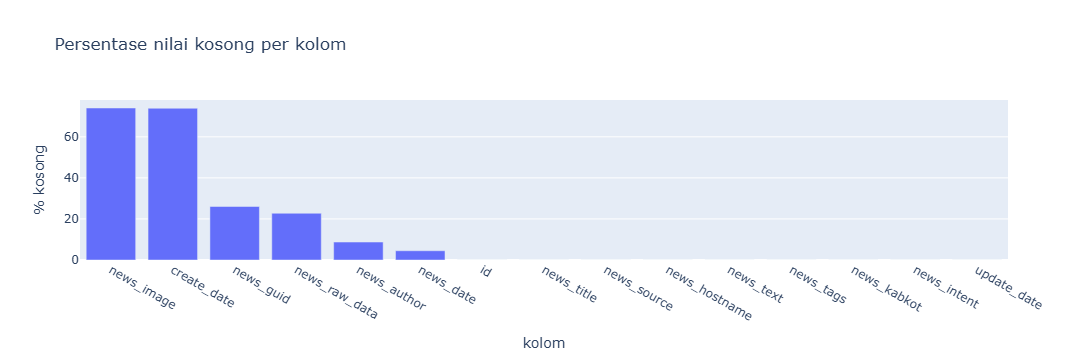

In [16]:
fig = px.bar(null_df, x="kolom", y="kosong_total_persen",
             title="Persentase nilai kosong per kolom",
             labels={"kosong_total_persen": "% kosong"})
fig.write_html(OUT_DIR / "figures" / "profiling_null_persen.html")
fig.show()

## Rentang waktu

In [17]:
DATE_COL = None   # misal: "published_at"

hints = ("date", "time", "publish", "created", "_at")
if DATE_COL is None:
    temporal = [c for c, t in schema.items() if t.is_temporal()]
    hinted = [c for c, t in schema.items() if t == pl.String and any(h in c.lower() for h in hints)]
    candidates = temporal + hinted
    print("Kandidat:", candidates)
    DATE_COL = candidates[0] if candidates else None
print("Kolom tanggal:", DATE_COL)

Kandidat: ['news_date', 'update_date', 'create_date']
Kolom tanggal: news_date


paling_awal,paling_akhir,null_atau_gagal_parse
"datetime[μs, UTC]","datetime[μs, UTC]",u32
0001-11-29 16:53:00 UTC,2569-03-20 09:52:00 UTC,60135


tahun,len
i32,u32
1,3
105,1
107,1
109,2
112,1
119,1
132,1
136,1
138,1


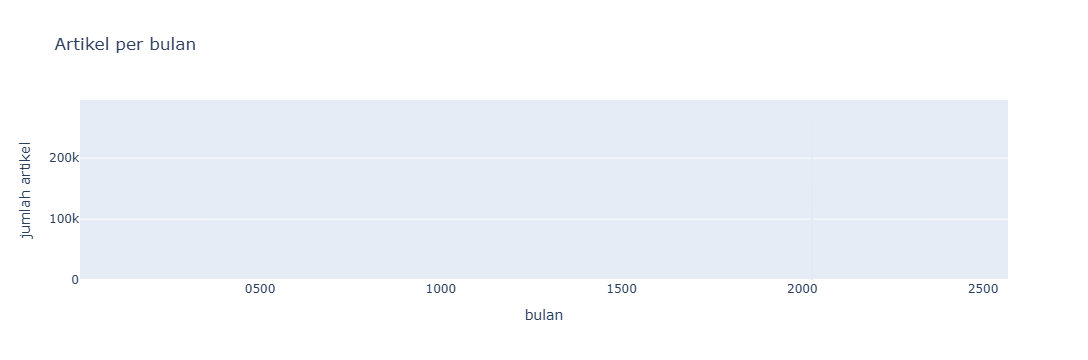

In [18]:
if DATE_COL:
    if schema[DATE_COL].is_temporal():
        date_expr = pl.col(DATE_COL)
    else:
        date_expr = pl.col(DATE_COL).str.to_datetime(strict=False, time_zone="UTC")

    dates = lf.select(date_expr.alias("tgl"))
    stats = collect(dates.select(
        pl.col("tgl").min().alias("paling_awal"),
        pl.col("tgl").max().alias("paling_akhir"),
        pl.col("tgl").null_count().alias("null_atau_gagal_parse"),
    ))
    display(stats)

    per_year = collect(
        dates.drop_nulls().group_by(pl.col("tgl").dt.year().alias("tahun")).len().sort("tahun")
    )
    display(per_year)

    per_month = collect(
        dates.drop_nulls().group_by(pl.col("tgl").dt.truncate("1mo").alias("bulan")).len().sort("bulan")
    )
    fig = px.bar(per_month, x="bulan", y="len", title="Artikel per bulan",
                 labels={"len": "jumlah artikel"})
    fig.write_html(OUT_DIR / "figures" / "profiling_artikel_per_bulan.html")
    fig.show()
else:
    print("Kolom tanggal tidak ketemu, isi DATE_COL manual.")

## Cek duplikat

In [19]:
key_names = ("id", "url", "link", "title")
key_cols = [c for c in scalar_cols if c.lower() in key_names]
print("Kolom yang dicek:", key_cols)

dup_rows = []
for c in key_cols:
    total, non_null, uniq = con.execute(
        f'SELECT count(*), count("{c}"), count(DISTINCT "{c}") FROM read_parquet({files_sql(FILES)})'
    ).fetchone()
    dup_rows.append({"kolom": c, "baris": total, "null": total - non_null,
                     "unik": uniq, "duplikat": non_null - uniq})
pl.DataFrame(dup_rows) if dup_rows else print("Tidak ada kolom kunci standar, tentukan manual.")

Kolom yang dicek: ['id']


kolom,baris,null,unik,duplikat
str,i64,i64,i64,i64
"""id""",1332236,0,1332236,0


## Kolom teks dan kolom bersarang

In [20]:
# panjang teks dan perkiraan jumlah nilai unik
card_exprs = []
for c in str_cols:
    card_exprs += [
        pl.col(c).approx_n_unique().alias(f"{c}__uniq"),
        pl.col(c).str.len_chars().mean().alias(f"{c}__mean_len"),
        pl.col(c).str.len_chars().max().alias(f"{c}__max_len"),
    ]
r = collect(lf.select(card_exprs)).row(0, named=True) if card_exprs else {}
card_df = pl.DataFrame([
    {"kolom": c, "unik_perkiraan": r[f"{c}__uniq"],
     "rata2_panjang": round(r[f"{c}__mean_len"] or 0, 1), "maks_panjang": r[f"{c}__max_len"]}
    for c in str_cols
]).sort("unik_perkiraan")
card_df

kolom,unik_perkiraan,rata2_panjang,maks_panjang
str,i64,f64,i64
"""news_kabkot""",942,15.2,42
"""news_hostname""",5636,14.0,46
"""news_author""",45438,14.3,236
"""create_date""",304775,32.0,32
"""news_image""",345309,102.2,454
"""news_tags""",828516,83.1,6493
"""news_date""",867012,25.1,32
"""news_guid""",1001787,298.5,1300
"""news_raw_data""",1060551,4103.9,448711


In [21]:
# nilai paling sering muncul di kolom yang unik-nya sedikit (sumber, kategori, dll)
low_card = card_df.filter((pl.col("unik_perkiraan") <= 500) & (pl.col("rata2_panjang") < 100))["kolom"].to_list()[:4]
for c in low_card:
    print(f"--- {c}")
    display(collect(lf.group_by(c).len().sort("len", descending=True).head(10)))

In [22]:
# lihat isi kolom bersarang
nested_cols = [c for c, t in schema.items() if t.is_nested()]
print("Kolom bersarang:", nested_cols)
for c in nested_cols:
    sample = collect(lf.select(c).drop_nulls().head(1))
    print(f"--- {c}: {schema[c]}")
    print(sample.item() if sample.height else "(semua null)")

Kolom bersarang: []


## Cek syarat Milestone 1

In [23]:
cek = {
    "Ukuran >= 500 MB atau baris > 1 juta": (total_bytes >= 500e6) or (N_ROWS > 1_000_000),
    "Baris > 1 juta (nilai tertinggi di rubrik)": N_ROWS > 1_000_000,
    "Ada kolom tanggal untuk analisis waktu": DATE_COL is not None,
    "data/README.md ada": Path(ROOT + "data/README.md").exists(),
}
for k, v in cek.items():
    print(("[OK]   " if v else "[CEK]  ") + k)

[OK]   Ukuran >= 500 MB atau baris > 1 juta
[OK]   Baris > 1 juta (nilai tertinggi di rubrik)
[OK]   Ada kolom tanggal untuk analisis waktu
[OK]   data/README.md ada
